# Data Analytics with Python: Assignment 1

## 1. Load and get to know the data

Load Titanic data as a dataframe. Answer verbally to the following questions:

1. What is the number of rows and columns?
2. How many missing values variable 'age' has?

In [ ]:
## code here
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('white')

# Load the Excel File
df = pd.read_excel('titanic.xlsx')

# Show first rows
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
# number of rows and columns
df.shape

(1309, 14)

In [ ]:
# missing values variable 'age' has?
df['age'].isna().sum()

np.int64(263)

Write here your answer to verbal questions.

1. Ans: Number of row and column are  1309 and 14

2. Ans: Missing values variable 'age' has 263
---



## 2. Create a frequency table for variable 'sex'. In addition to that, create a column chart (bar chart with vertical bars) illustrating the frequency table. Answer verbally to the following questions:

1. What was the number of males on Titanic?
2. What was the percentage of men of all passengers?

In [ ]:
## code here
# frequency table
df1 = pd.crosstab(df['sex'] , 'f')

# drop col_0
df1.columns.name = ''

# add percentage column
n = df1['f'].sum()
df1['%'] = df1['f']/n*100

# total row
df1.loc['Total'] = df1.sum()

df1.style.format({'f': '{:.0f}' , '%': '{:.1f}%'})

,f,%
sex,,
female,466,35.6%
male,843,64.4%
Total,1309,100.0%


[Text(0, 0, '466'), Text(0, 0, '843')]

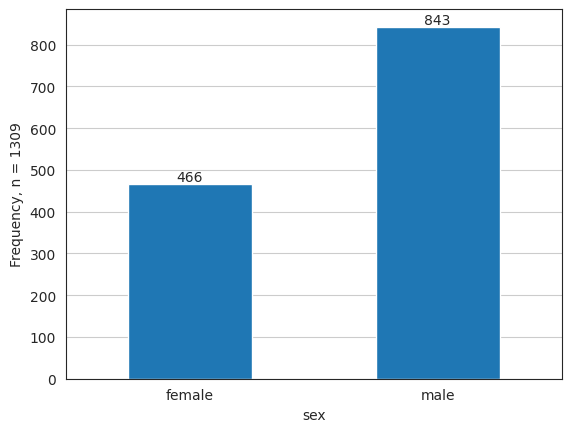

In [ ]:
# create a bar chart to illustrate f column without total row

# drop total row
df2 = df1.drop('Total')

# create simple bar chart
df2['f'].plot(kind='bar')

# x-axis title
plt.ylabel(f'Frequency, n = {n}')

# add grid
plt.grid(axis='y')

# Make x-axis labels horizontal
plt.xticks(rotation=0)

# simple way to add labels
plt.gca().bar_label(plt.gca().containers[0], label_type='edge')

Write here your answer to verbal questions.
1. Ans: Number of male 843
2. Ans: Percentage of men of all passengers 64.4%

## 3. Filter data in the following way: Include only third class passenger who are older than 40 years. Answer verbally how many such passengers there were on Titanic.

In [ ]:
## code here
# Filter: third class passengers older than 40
df3 = df[(df['pclass'] == 3) & (df['age'] > 40)]

# Count how many
count_passenger = len(df3)

count_passenger

48

Write here your answer to verbal question.
Ans: 40 passangers are hird class passengers who are older than 40 years

## 4. Calculate common statistical numbers (at least the following descibtive statistics: mean, median, standard deviation, lower quartile and upper quartile) of variable 'age'. Answer verbally to the following questions:
1. How old was the oldest passenger?
2. What is the median age of all passengers?

In [ ]:
## code here
df4 = df['age'].describe().round(1)

df4

,age
count,1046.0
mean,29.9
std,14.4
min,0.2
25%,21.0
50%,28.0
75%,39.0
max,80.0


Write here your answer to verbal questions.
1. Ans: Oldest pessanger 80 years old.

2. Ans: Median age of all passengers 28 years.

## 5. Crosstabulate variables 'sex' and 'survived' such that values are presented as percentages. Percentages should correspond the fractions of survived passengers per gender. Answer verbally to the following questions:
1. What percentage of males survived?
2. How would you describe the difference in surviving probability between men and women?

In [ ]:
## code here
# crosstab with percentages per gender
df5 = pd.crosstab(df['sex'],
                  df['survived'],
                  normalize='index') * 100

df5 = df5.round(1)

df5.style.format('{:.1f}%')

survived,0,1
sex,,
female,27.3%,72.7%
male,80.9%,19.1%


In [ ]:
survival_prob = pd.crosstab(df['sex'],
                            df['survived'],
                            normalize='index')[1]

survival_prob = survival_prob.round(3)

survival_prob

,1
sex,
female,0.727
male,0.191


Write here your answer to verbal question.
1. Ans: 19.1% male survived
2. Ans: Women had a significantly higher survival probability than men.Women survived probability 0.71 where men only 0.19 surviving probability.

## 6. Create a frequency table for 'age' such that values are classified into bins of size 10 years each. The lower limit of the first bin should be 0 years. In addition to that, illustrate the age distribution with a histogram corresponding the frequency table (with same bins). Answer verbally to the following question: Which age group is the largest?

In [ ]:
## code here
# create bins from 0 to 80 (adjust upper limit if needed)
bins = range(0, 90, 10)

# create age groups
df['age_group'] = pd.cut(df['age'],
                         bins=bins,
                         right=False)

df['age_group'].head()

,age_group
0,"[20, 30)"
1,"[0, 10)"
2,"[0, 10)"
3,"[30, 40)"
4,"[20, 30)"


In [ ]:
# frequency table
age_freq = df['age_group'].value_counts().sort_index()

age_freq

,count
age_group,
"[0, 10)",82
"[10, 20)",143
"[20, 30)",344
"[30, 40)",232
"[40, 50)",135
"[50, 60)",70
"[60, 70)",32
"[70, 80)",7


[Text(0, 0, '82'),
 Text(0, 0, '143'),
 Text(0, 0, '344'),
 Text(0, 0, '232'),
 Text(0, 0, '135'),
 Text(0, 0, '70'),
 Text(0, 0, '32'),
 Text(0, 0, '8')]

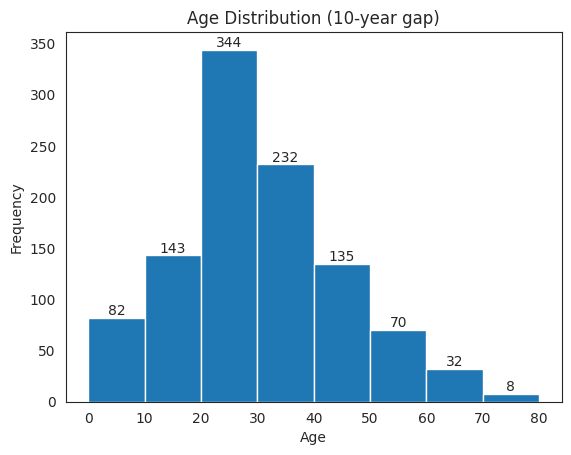

In [ ]:
plt.hist(df['age'].dropna(),
         bins=bins)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution (10-year gap)')
# simple way to add labels
plt.gca().bar_label(plt.gca().containers[0], label_type='edge')

Write here your answer to verbal question.
Ans: 20- 29 age group is the largest 344 people.  

## 7. Study the connection of passenger fare between and passenger classes in the following way: Create a table showing typical statistical numbers of passenger fare separately in each passenger class. In addition to that, illustrate this table with a corresponding boxplot figure. Answer verbally to the following questions:
1. What was the mean passenger fare in second passenger class?
2. How would you describe the connection between passenger class and passenger fare?

In [ ]:
## code here
# descriptive statistics of fare by passenger class
fare_stats = df.groupby('pclass')['fare'].describe().round(2)

fare_stats

,count,mean,std,min,25%,50%,75%,max
pclass,,,,,,,,
1,323.0,87.51,80.45,0.0,30.70,60.00,107.66,512.33
2,277.0,21.18,13.61,0.0,13.00,15.05,26.00,73.50
3,708.0,13.30,11.49,0.0,7.75,8.05,15.25,69.55


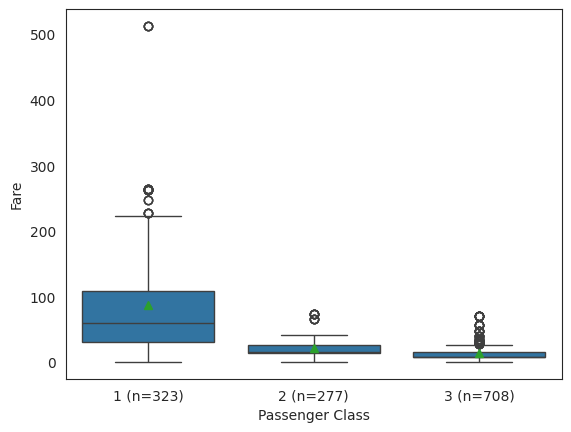

In [ ]:
sns.boxplot(data=df, y='fare', x='pclass', showmeans=True)

# n-values
class1 = df[df['pclass']==1]['fare'].count()
class2 = df[df['pclass']==2]['fare'].count()
class3 = df[df['pclass']==3]['fare'].count()

# x-axis
plt.xticks([0,1,2],
           [f'1 (n={class1})',
            f'2 (n={class2})',
            f'3 (n={class3})'])

plt.xlabel('Passenger Class')
plt.ylabel('Fare')

plt.show()

Write here your answer to verbal question.
1. Ans: Mean fare of second class passanger is 21.18

2. Ans: Passenger fare is strongly associated with passenger class. Higher-class passengers (1st class) paid significantly higher fares, while lower-class passengers (3rd class) paid substantially lower fares. The boxplot also indicates greater variability in fares within the first class.

## 8. Calculate the correlation coefficient between passenger fare and age. In addition to that, create a chart illustrating the connection between these two variables. Answer verbally to the following questions:
1. Is the connection between these variables positive or negative?
2. Do these two variables have strong or weak connection? What does this mean in practice? **Justify your answer.**

In [ ]:
## code here
# correlation between fare and age
correlation = df[['fare', 'age']].corr().loc['fare', 'age']

print(f"Correlation coefficient: {correlation:.3f}")

Correlation coefficient: 0.179


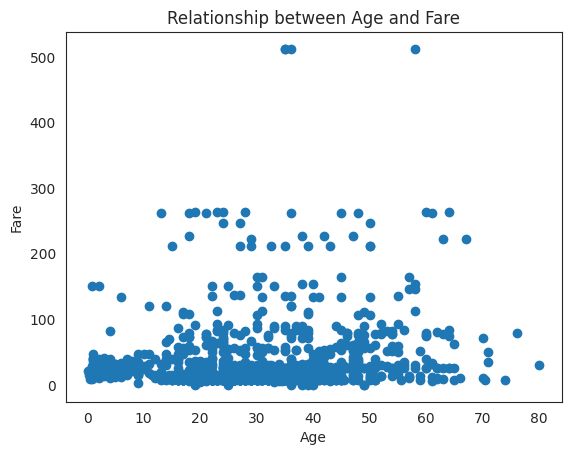

In [ ]:
plt.figure()

plt.scatter(df['age'], df['fare'])

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Relationship between Age and Fare')

plt.show()

Write here your answer to verbal questions.

Ans: The correlation coefficient between passenger fare and age is approximately 0.179 The relationship is positive but weak. This means that older passengers tended to pay slightly higher fares, but the association is very small. In practice, age does not strongly determine the ticket price.